# Spotify Data Visualization Project

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [219]:
df = pd.read_csv('https://raw.githubusercontent.com/MainakRepositor/Datasets/refs/heads/master/Billboard%201990.csv')

## Data Preprocessing

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Chart Position    100 non-null    int64 
 1   Title             100 non-null    object
 2   Artist            100 non-null    object
 3   Genre             100 non-null    object
 4   Subgenre          97 non-null     object
 5   Spotify Streams   98 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


In [221]:
df.head()

,Chart Position,Title,Artist,Genre,Subgenre,Spotify Streams
0,1,"""Hold On""",Wilson Phillips,Pop,Adult Contemporary,"125,755,976"
1,2,"""It Must Have Been Love""",Roxette,Pop Rock,Adult Contemporary,"333,690,809"
2,3,"""Nothing Compares 2 U""",Sinéad O'Connor,Pop,Adult Contemporary,"208,150,170"
3,4,"""Poison""",Bell Biv DeVoe,R&B,New Jack Swing,"157,501,896"
4,5,"""Vogue""",Madonna,Pop,Dance-Pop,"163,481,756"


In [222]:
df.tail()

,Chart Position,Title,Artist,Genre,Subgenre,Spotify Streams
95,96,"""Without You""",Mötley Crüe,Metal,Glam Metal,"21,856,658"
96,97,"""Swing the Mood""",Jive Bunny and the Mastermixers,Swing,Swing Revival,"11,490,469"
97,98,"""Thieves in the Temple""",Prince,Pop Soul,R&B,"5,735,706"
98,99,"""Mentirosa""",Mellow Man Ace,Rap,Latin Rap,"3,600,707"
99,100,"""Tic-Tac-Toe""",Kyper,Pop Rap,Electro,"299,445"


In [223]:
df.columns

Index(['Chart Position', 'Title', 'Artist', 'Genre', 'Subgenre',
       'Spotify Streams '],
      dtype='object')

In [224]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [228]:
# Change columns to integer (right now they are object)
df['Spotify Streams '] = (df['Spotify Streams '].astype(str).str.replace(",","", regex=False).str.strip().astype("int64"))

In [232]:
# Total Number of Spotify Streams
df.describe()

,Chart Position,Spotify Streams
count,95.000000,9.500000e+01
mean,49.694737,5.909535e+07
std,29.087935,8.981376e+07
min,1.000000,6.931400e+04
25%,24.500000,4.787670e+06
50%,50.000000,2.183960e+07
75%,74.500000,6.302816e+07
max,100.000000,4.369353e+08


In [233]:
df['Spotify Streams '].sum()

np.int64(5614058402)

...that's a lot of streams.

In [234]:
genres = df['Genre'].value_counts()

genres

,count
Genre,
Pop,25
R&B,24
Pop Rock,21
Pop Rap,7
Metal,6
Pop Soul,5
Rock,3
Rap,2
Soul,1


In [235]:
subgenres = df['Subgenre'].value_counts()

subgenres

,count
Subgenre,
Adult Contemporary,23
New Jack Swing,18
Dance-Pop,10
Hard Rock,5
Glam Metal,5
AOR,5
House,4
Soul,2
New Wave,2


In [236]:
artists = df['Artist'].value_counts()

artists

,count
Artist,
Janet Jackson,5
Phil Collins,4
Michael Bolton,3
Taylor Dayne,3
Mariah Carey,2
...,...
Mötley Crüe,1
Jive Bunny and the Mastermixers,1
Prince,1


## Data Visualizations

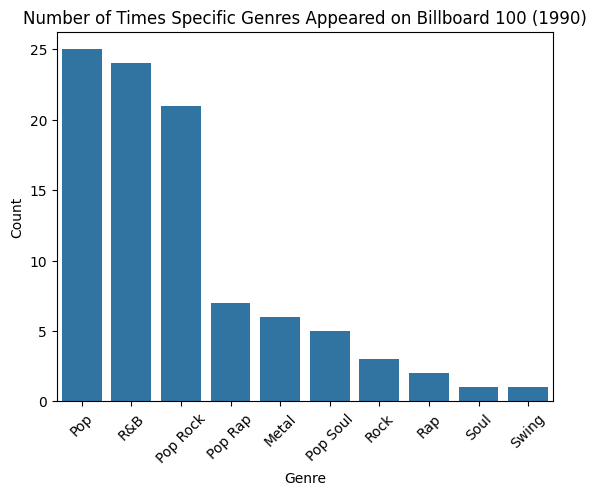

In [237]:
sns.barplot(genres)

plt.title('Number of Times Specific Genres Appeared on Billboard 100 (1990)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

Pop was the most popular genre, followed by R&B and Pop Rock.

In [238]:
px.bar(subgenres.reset_index(),
       x='count', y='Subgenre',
       labels={'count' : 'Count'},
       title='Number of Times Specific Subgenres Appeared on Billboard 100 (1990)')


Adult contemporary was the most popular subgenre, followed by New Jack Swing and dance-pop.

In [239]:
px.bar(artists.reset_index(), # Makes sure it's not aggregated so x and y can be swapped
       x='count', y='Artist',
       labels={ 'count' : 'Count'},
       title='Number of Times Specific Artists Appeared on the Billboard 100 (1990)')

Artist that appeared on the Billboard 100 in 1990 the most: Janet Jackson


In [242]:
px.bar(df.reset_index(),
       x='Title', y='Spotify Streams ',
       labels={'Title' : 'Song Title'},
       title='Number of Spotify Streams for Each Song')